<a href="https://colab.research.google.com/github/mariacastrom00/AI_exercises_MJCM/blob/main/assignment4_MJCM_AH2179.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises before assignment 4
By: Maria José Castro Moreno
Course: AH2179

## Data preparation


In [3]:
%pip install factor_analyzer

In [4]:
import pandas as pd
import numpy as np

# Import for task 1
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Import for task 2
import matplotlib.pyplot as plt
from sklearn.decomposition import KernelPCA

# Import for task 3
from sklearn.datasets import make_classification
# pip install factor_analyzer
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# Import for task 3.3
from sklearn.decomposition import PCA, KernelPCA
import matplotlib.pyplot as plt

,PORTAL,Date,time_from,time_to,Interval_5,SPEED_MS_AVG,flow
0,"E4S 56,780",20210101,00:00:00,00:05:00,0,18.56,39
1,"E4S 56,780",20210101,00:05:00,00:10:00,1,20.39,18
2,"E4S 56,780",20210101,00:10:00,00:15:00,2,19.27,26
3,"E4S 56,780",20210101,00:15:00,00:20:00,3,19.52,52
4,"E4S 56,780",20210101,00:20:00,00:25:00,4,20.52,52
...,...,...,...,...,...,...,...
104838,"E4S 56,780",20211231,23:35:00,23:40:00,283,19.58,115
104839,"E4S 56,780",20211231,23:40:00,23:45:00,284,19.47,87
104840,"E4S 56,780",20211231,23:45:00,23:50:00,285,19.77,130
104841,"E4S 56,780",20211231,23:50:00,23:55:00,286,18.79,129


# Assignment 4 - Neural network model for bike-sharing demand prediction

In [20]:
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'

df = pd.read_csv(url)

df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [21]:
print(df.shape)
print(df.columns)

df.info()

(17379, 17)
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casua

In [22]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [23]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [25]:
# Remove target and variables that would cause data leakage

columns_to_drop = ['cnt']

if 'casual' in df.columns:
    columns_to_drop.append('casual')

if 'registered' in df.columns:
    columns_to_drop.append('registered')

X = df.drop(columns=columns_to_drop)
y = df['cnt']

print("Input variables:")
print(X.columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input variables:
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')

X shape: (17379, 14)
y shape: (17379,)


In [26]:
print(X.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
dtype: object


In [28]:
# Remove columns that should not be used as predictors

# First try
X = df.drop(columns=[
    'dteday',   # date as text/object
    'instant',  # just an ID/index
    'casual',   # remove if present - causes data leakage
    'registered', # remove if present - causes data leakage
    'cnt'       # target variable
], errors='ignore')

y = df['cnt']


In [29]:
print(X.columns)
print(X.dtypes)

print("X shape:", X.shape)
print("y shape:", y.shape)

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
dtype: object
X shape: (17379, 12)
y shape: (17379,)


In [30]:
# Train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (13903, 12)
Test set: (3476, 12)


In [31]:
# Scale predictors

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(13903, 12)
(3476, 12)


### Model 1

In [48]:
%pip install tensorflow.keras

In [49]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [50]:
# Compiling
baseline_model = Sequential([
    Dense(32,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)), Dense(1)])

baseline_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449 (1.75 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Training
baseline_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'])

In [53]:
history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)

Epoch 1/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 67119.7969 - mae: 186.3813 - val_loss: 62585.1602 - val_mae: 176.0579
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 54095.4609 - mae: 162.8732 - val_loss: 44540.6250 - val_mae: 142.6806
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 36581.5781 - mae: 127.9304 - val_loss: 29607.0625 - val_mae: 112.6398
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 26353.5918 - mae: 108.2594 - val_loss: 23627.7402 - val_mae: 102.7146
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 22780.4316 - mae: 102.7176 - val_loss: 21594.7695 - val_mae: 100.3853
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 21385.7480 - mae: 101.4430 - val_loss: 20734.9199 - val_mae: 100.4479
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 20717.1113 - mae: 101.7685 - val_loss: 20331.3145 - val_mae: 101.1146
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 20353.4922 - mae: 102.

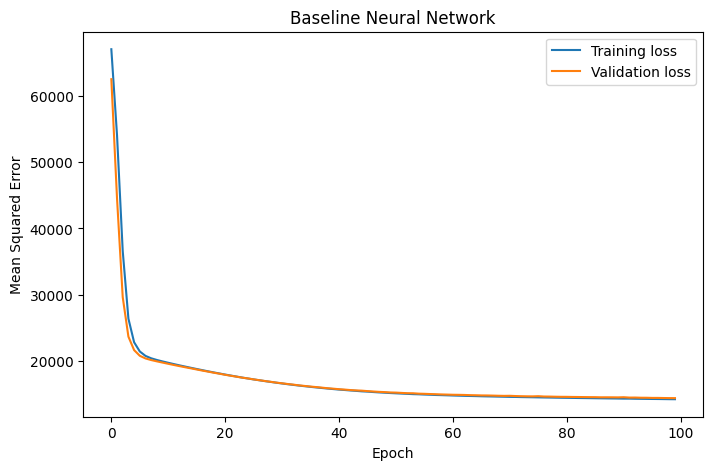

In [54]:
# MODEL 1
# Plot of learning curves
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['loss'], label='Training loss')

plt.plot(history_baseline.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Baseline Neural Network')
plt.legend()

plt.show()

In [56]:
# Evaluation of model 1
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred_baseline = baseline_model.predict(X_test_scaled).flatten()

mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print("MSE:", mse_baseline)
print("RMSE:", rmse_baseline)
print("MAE:", mae_baseline)
print("R²:", r2_baseline)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE: 13801.31640625
RMSE: 117.47900410818096
MAE: 87.99996185302734
R²: 0.5641517043113708


### Model 2 - Larger neural network

In [51]:
# Model 2: Larger neural network

model_2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)])

model_2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'])

history_2 = model_2.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)

Epoch 1/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 42832.4883 - mae: 140.5985 - val_loss: 20460.0566 - val_mae: 105.0152
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 20268.0977 - mae: 104.6784 - val_loss: 20042.4961 - val_mae: 103.2403
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 19964.6348 - mae: 103.7458 - val_loss: 19824.4395 - val_mae: 103.8241
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 19766.7285 - mae: 103.4184 - val_loss: 19645.1816 - val_mae: 103.0694
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 19595.7754 - mae: 102.8363 - val_loss: 19520.3789 - val_mae: 101.2473
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 19447.7363 - mae: 102.1798 - val_loss: 19328.7207 - val_mae: 101.9167
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 19290.0879 - mae: 101.7768 - val_loss: 19186.2109 - val_mae: 101.8936
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 19153.7090 - mae: 101

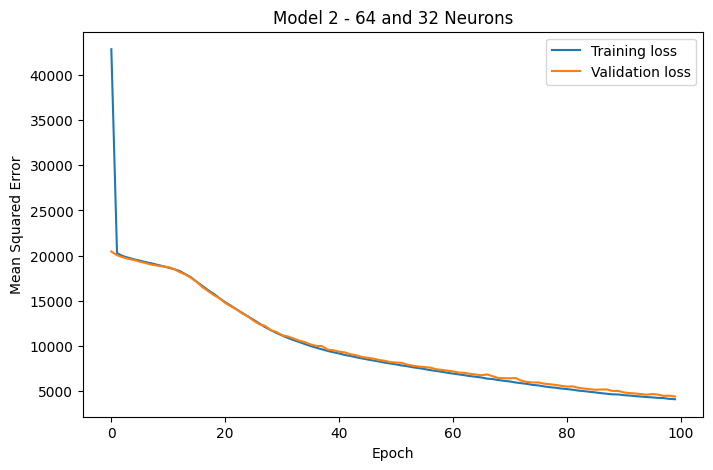

In [55]:
# MODEL 2
plt.figure(figsize=(8,5))

plt.plot(history_2.history['loss'], label='Training loss')
plt.plot(history_2.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Model 2 - 64 and 32 Neurons')
plt.legend()

plt.show()

In [57]:
# Evaluation of model 2
y_pred_2 = model_2.predict(X_test_scaled).flatten()

mse_2 = mean_squared_error(y_test, y_pred_2)
rmse_2 = np.sqrt(mse_2)
mae_2 = mean_absolute_error(y_test, y_pred_2)
r2_2 = r2_score(y_test, y_pred_2)

print("Model 2 MSE:", mse_2)
print("Model 2 RMSE:", rmse_2)
print("Model 2 MAE:", mae_2)
print("Model 2 R²:", r2_2)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 2 MSE: 4169.59375
Model 2 RMSE: 64.57239154623282
Model 2 MAE: 43.142601013183594
Model 2 R²: 0.8683233857154846


## Model 3 - Larger architecture

In [58]:
# Model 3: Larger neural network
model_3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model_3.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_3 = model_3.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 29258.9531 - mae: 120.5853 - val_loss: 20086.8848 - val_mae: 103.3889
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 19905.8809 - mae: 103.5382 - val_loss: 19358.0020 - val_mae: 100.6488
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 18091.2852 - mae: 97.0804 - val_loss: 16245.6611 - val_mae: 87.8017
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 14819.2725 - mae: 87.0221 - val_loss: 13471.2637 - val_mae: 82.7862
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 12582.0938 - mae: 78.9585 - val_loss: 11926.0449 - val_mae: 75.0209
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 11295.0674 - mae: 73.9791 - val_loss: 10929.6084 - val_mae: 70.1532
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 10210.5869 - mae: 69.5194 - val_loss: 9990.0205 - val_mae: 67.5844
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9365.5195 - mae: 65.8328 - val_loss: 9221.341

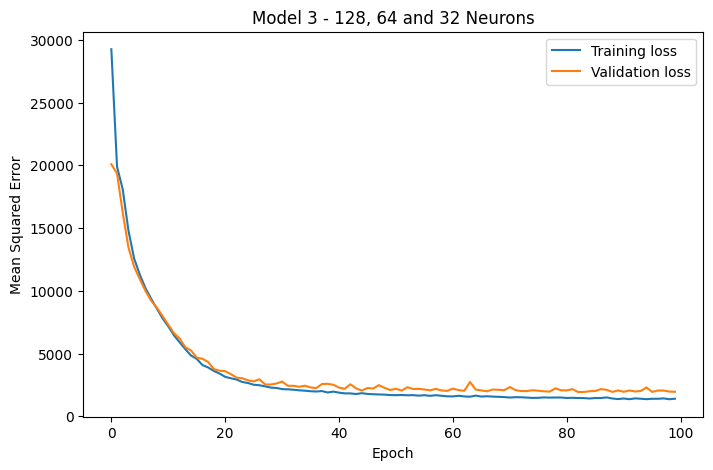

In [59]:
plt.figure(figsize=(8,5))

plt.plot(history_3.history['loss'], label='Training loss')
plt.plot(history_3.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Model 3 - 128, 64 and 32 Neurons')
plt.legend()

plt.show()

In [60]:
y_pred_3 = model_3.predict(X_test_scaled).flatten()

mse_3 = mean_squared_error(y_test, y_pred_3)
rmse_3 = np.sqrt(mse_3)
mae_3 = mean_absolute_error(y_test, y_pred_3)
r2_3 = r2_score(y_test, y_pred_3)

print("Model 3 MSE:", mse_3)
print("Model 3 RMSE:", rmse_3)
print("Model 3 MAE:", mae_3)
print("Model 3 R²:", r2_3)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 3 MSE: 1763.0548095703125
Model 3 RMSE: 41.98874622527222
Model 3 MAE: 26.097078323364258
Model 3 R²: 0.944322407245636


## Model 4 - Model 3 + Dropouts

In [62]:
from tensorflow.keras.layers import Dropout

# Model 4: Model 3 with dropout

model_4 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)])

model_4.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'])

history_4 = model_4.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 29607.2051 - mae: 121.5100 - val_loss: 20303.7656 - val_mae: 106.1142
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20551.5820 - mae: 104.8980 - val_loss: 19740.0078 - val_mae: 103.6944
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 20144.9238 - mae: 103.5594 - val_loss: 20173.6035 - val_mae: 98.6257
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 19571.4727 - mae: 100.9623 - val_loss: 18393.1699 - val_mae: 98.4333
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 18438.8848 - mae: 96.9411 - val_loss: 16989.8027 - val_mae: 90.3748
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17087.0488 - mae: 92.2928 - val_loss: 15547.5234 - val_mae: 85.2839
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 15894.2324 - mae: 87.5279 - val_loss: 14066.0342 - val_mae: 81.6027
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 14615.8330 - mae: 83.1906 - val_loss: 1313

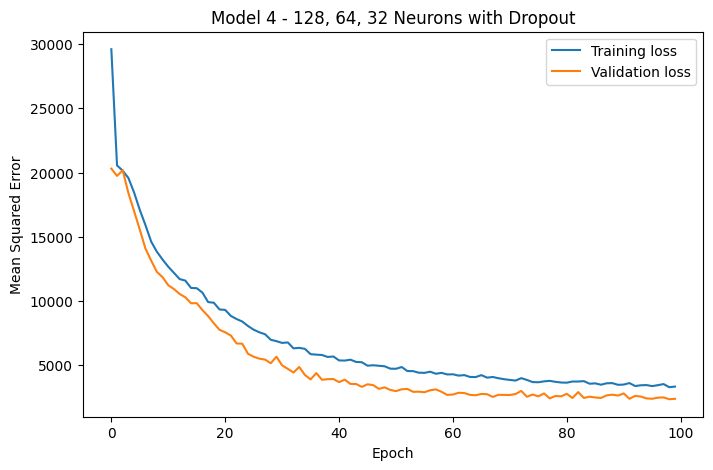

In [63]:
plt.figure(figsize=(8,5))

plt.plot(history_4.history['loss'], label='Training loss')
plt.plot(history_4.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Model 4 - 128, 64, 32 Neurons with Dropout')
plt.legend()

plt.show()

In [64]:
y_pred_4 = model_4.predict(X_test_scaled).flatten()

mse_4 = mean_squared_error(y_test, y_pred_4)
rmse_4 = np.sqrt(mse_4)
mae_4 = mean_absolute_error(y_test, y_pred_4)
r2_4 = r2_score(y_test, y_pred_4)

print("Model 4 MSE:", mse_4)
print("Model 4 RMSE:", rmse_4)
print("Model 4 MAE:", mae_4)
print("Model 4 R²:", r2_4)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 4 MSE: 2265.177978515625
Model 4 RMSE: 47.59388593627993
Model 4 MAE: 30.76277732849121
Model 4 R²: 0.9284652471542358


## Model 5 - Model 3 training with ModelCheckpoint and EarlyStopping

In [66]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Model 5: Model 3 architecture with callbacks

model_5 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model_5.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

checkpoint = ModelCheckpoint(
    'best_bike_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_5 = model_5.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


344/348 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 43864.6439 - mae: 147.9191
Epoch 1: val_loss improved from None to 20159.05273, saving model to best_bike_model.keras

Epoch 1: finished saving model to best_bike_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 29533.0137 - mae: 121.8136 - val_loss: 20159.0527 - val_mae: 103.1838
Epoch 2/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20017.6854 - mae: 103.8640
Epoch 2: val_loss improved from 20159.05273 to 19404.67969, saving model to best_bike_model.keras

Epoch 2: finished saving model to best_bike_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 19924.4180 - mae: 103.3250 - val_loss: 19404.6797 - val_mae: 102.9157
Epoch 3/200
347/348 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18902.9659 - mae: 100.3237
Epoch 3: val_loss improved from 19404.67969 to 17394.11133, saving model to best_bike_model.keras

Epoch 3: finished saving model to best_bike_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 18

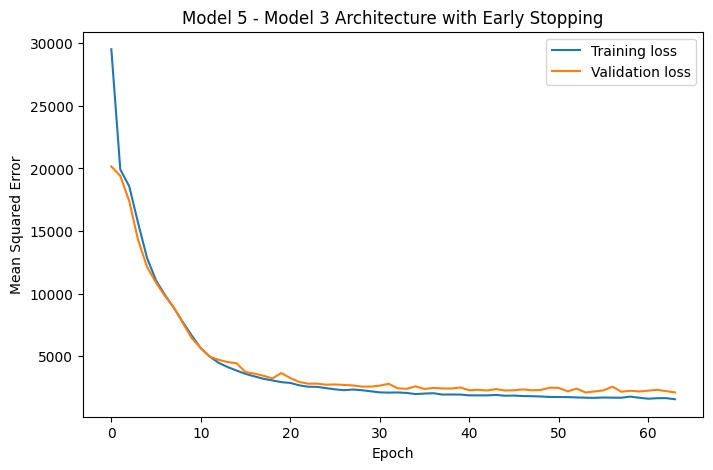

In [67]:
plt.figure(figsize=(8,5))

plt.plot(history_5.history['loss'], label='Training loss')
plt.plot(history_5.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Model 5 - Model 3 Architecture with Early Stopping')
plt.legend()

plt.show()

In [68]:
from tensorflow.keras.models import load_model

best_model = load_model('best_bike_model.keras')

In [69]:
y_pred_best = best_model.predict(X_test_scaled).flatten()

mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Best Model MSE:", mse_best)
print("Best Model RMSE:", rmse_best)
print("Best Model MAE:", mae_best)
print("Best Model R²:", r2_best)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best Model MSE: 1978.5001220703125
Best Model RMSE: 44.48033410475142
Best Model MAE: 28.812397003173828
Best Model R²: 0.9375185966491699


In [70]:
results_final = pd.DataFrame({
    'Model': [
        'Baseline',
        'Model 2',
        'Model 3',
        'Model 4',
        'Best saved model'
    ],

    'Architecture': [
        '32',
        '64-32',
        '128-64-32',
        '128-64-32 + Dropout',
        '128-64-32 + EarlyStopping'
    ],

    'RMSE': [
        rmse_baseline,
        rmse_2,
        rmse_3,
        rmse_4,
        rmse_best
    ],

    'MAE': [
        mae_baseline,
        mae_2,
        mae_3,
        mae_4,
        mae_best
    ],

    'R2': [
        r2_baseline,
        r2_2,
        r2_3,
        r2_4,
        r2_best
    ]
})

results_final

,Model,Architecture,RMSE,MAE,R2
0,Baseline,32,117.479004,87.999962,0.564152
1,Model 2,64-32,64.572392,43.142601,0.868323
2,Model 3,128-64-32,41.988746,26.097078,0.944322
3,Model 4,128-64-32 + Dropout,47.593886,30.762777,0.928465
4,Best saved model,128-64-32 + EarlyStopping,44.480334,28.812397,0.937519


## Actual VS Predicted plot - Model 3

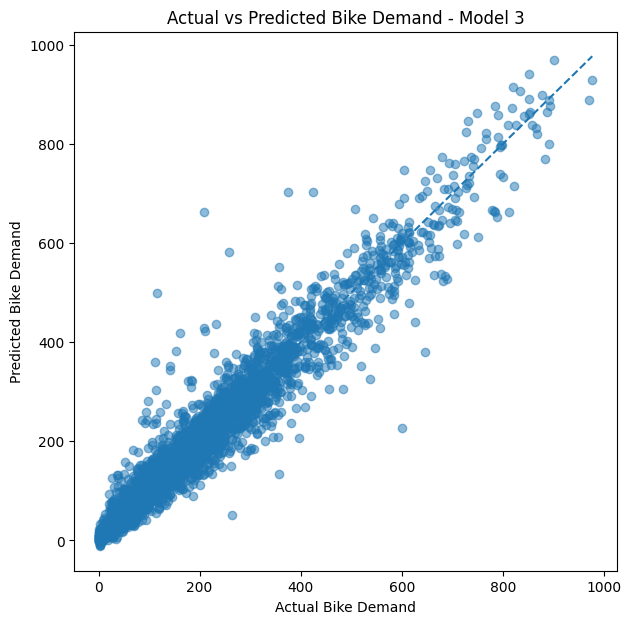

In [71]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred_3,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Bike Demand')
plt.ylabel('Predicted Bike Demand')
plt.title('Actual vs Predicted Bike Demand - Model 3')

plt.show()

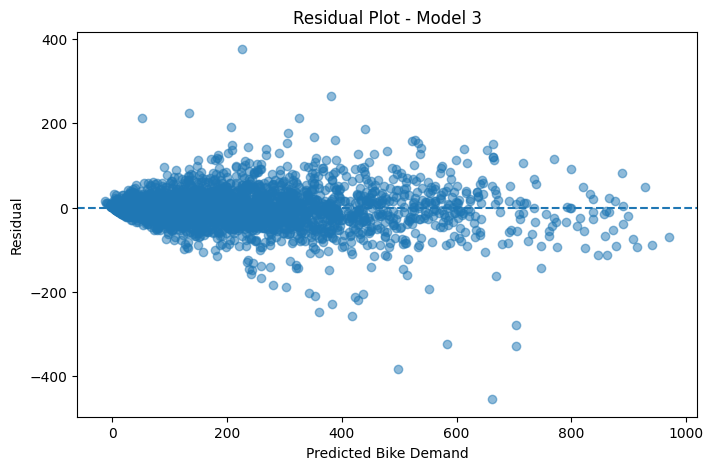

In [72]:
residuals_3 = y_test - y_pred_3

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_3,
    residuals_3,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Bike Demand')
plt.ylabel('Residual')
plt.title('Residual Plot - Model 3')

plt.show()